# Iris Flower Classification

## Project Overview

This project focuses on classifying Iris flowers into three species: **Iris-setosa, Iris-versicolor, and Iris-virginica** using machine learning.

The classification is based on four flower measurements:

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

The project follows a complete machine learning workflow including data loading, data exploration, data quality checking, exploratory data analysis, preprocessing, model training, evaluation, and prediction.

### Objective

The main objective is to develop machine learning models that can accurately predict the species of an Iris flower based on its physical measurements.

### Technologies Used

1. Python
2. Pandas
3. NumPy
4. Matplotlib
5. Seaborn
6. Scikit-learn
9. Jupyter Notebook

In [43]:
import sys
sys.path.append(r"D:\Lib\site-packages")

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [41]:
import zipfile
with zipfile.ZipFile("iris.zip", "r") as zip_ref:
    zip_ref.extractall()

In [42]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Initial Data Understanding

Before cleaning and analyzing the dataset, we first examine its structure, columns, size, and basic statistics.

In [12]:
print("Dataset shape:", df.shape)

Dataset shape: (150, 6)


In [13]:
print("Column names:")
print(df.columns)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


## Data Quality Check

The dataset is checked for missing values and duplicate records before further analysis.

In [15]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [16]:
print("Flower species:")
print(df["Species"].unique())

Flower species:
<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


In [17]:
print(df["Species"].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [18]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## - Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of the Iris species and identify relationships between the flower measurements.

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


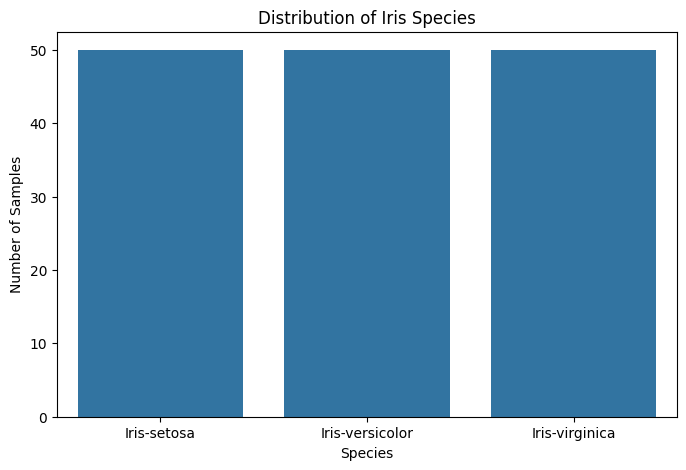

In [23]:
species_counts = df["Species"].value_counts()

print(species_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Species"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.show()

**Observation:**  
Each Iris species; specifically Iris-setosa, Iris-versicolor, and Iris-virginica, contains exactly 50 samples, showing that the dataset is completely balanced across all three classes

### Relationship Between Petal Measurements

The relationship between petal length and petal width is visualized to examine how well these features distinguish the different Iris species.

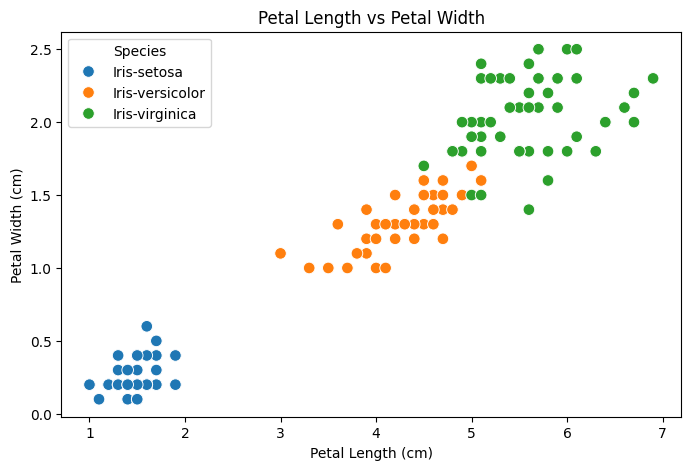

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=70
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.show()

**Observation:**  
The species form distinct groups based on petal length and width, with Iris-setosa completely separated at lower values (petal length 1.0–1.9 cm, petal width 0.1–0.6 cm), while Iris-versicolor (length 3.0–5.1 cm, width 1.0–1.7 cm) and Iris-virginica (length 4.5–6.9 cm, width 1.4–2.5 cm) show a minor overlap in the 4.5–5.1 cm length range.

### Feature Correlation

A correlation heatmap is used to identify relationships between the numerical flower measurements.

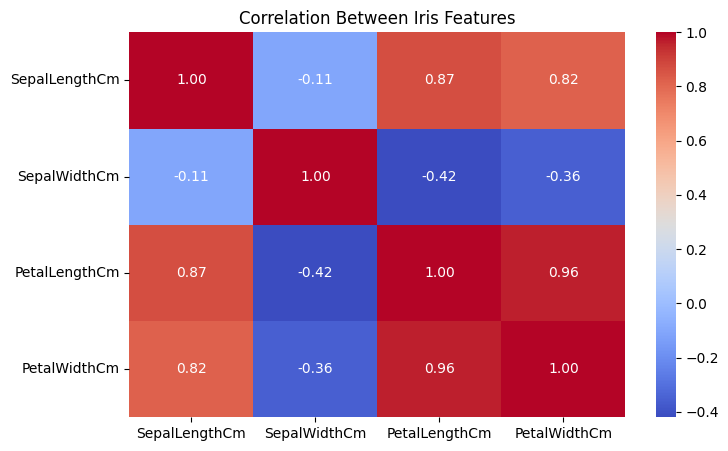

In [25]:
features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

correlation = df[features].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Iris Features")
plt.show()

**Observation:**  
ObservationPetal length and petal width show a very strong positive correlation of $0.96$, making them highly effective features for distinguishing Iris species, whereas sepal width exhibits weak negative correlations with petal length ($-0.42$) and petal width ($-0.36$).

## - Data Preprocessing

The dataset is prepared for machine learning by removing the unnecessary ID column, separating the input features from the target variable, and splitting the data into training and testing sets.

In [26]:
df_ml = df.drop(columns=["Id"])

print("Dataset after removing Id:")
print(df_ml.head())

Dataset after removing Id:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


### Separating Features and Target

The four flower measurements are used as input features, while the species is the target variable.

In [27]:
X = df_ml[features]
y = df_ml["Species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target:
Species


### Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the models, while the testing data is used to evaluate their performance on unseen samples.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


## - Machine Learning Model Training

Three classification algorithms are trained to predict the species of Iris flowers:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Using different types of models allows us to compare their classification performance on the same dataset.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [30]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [31]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### Model Training Summary

Three classification models were successfully trained using the Iris flower measurements. Logistic Regression was trained using scaled features, while Decision Tree and Random Forest were trained using the original feature values.

## - Model Evaluation

The trained models are evaluated on the unseen test data using Accuracy, Precision, Recall, and F1-Score.

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_results = []

models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

for model_name, predictions in models.items():
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="weighted"
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted"
        ),
        "F1-Score": f1_score(
            y_test, predictions, average="weighted"
        )
    })

results_df = pd.DataFrame(model_results)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933,0.933,0.933,0.933
1,Decision Tree,0.933,0.933,0.933,0.933
2,Random Forest,0.900,0.902,0.900,0.900


**Observation**

Logistic Regression and Decision Tree tie for the best performance, each achieving an accuracy, precision, recall, and F1-score of 0.933, outperforming Random Forest which scores 0.900.

### Model Performance Comparison

The following chart compares the performance of the three classification models across the selected evaluation metrics.

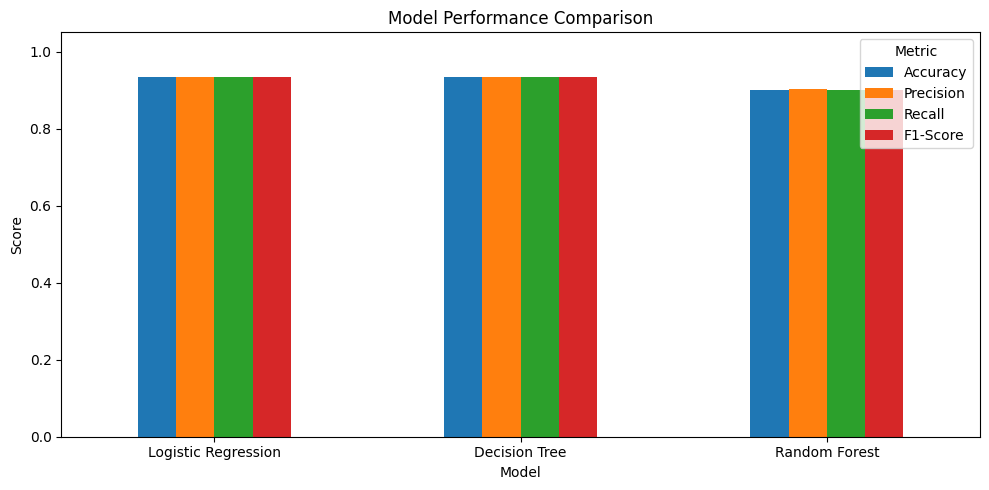

In [33]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

**Observation**

Logistic Regression and Decision Tree perform identically, each achieving scores of approximately 0.93 across Accuracy, Precision, Recall, and F1-Score, slightly outperforming Random Forest which scores around 0.90 across all metrics.

## - Confusion Matrix

A confusion matrix is used to examine how accurately the selected model classifies each Iris species and where classification errors occur.

Selected Model: Logistic Regression


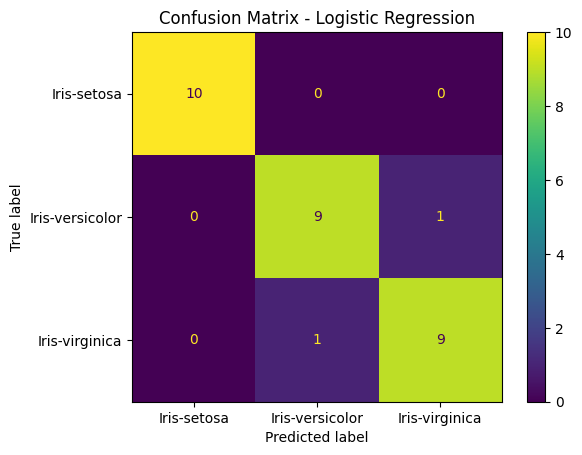

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Select the model with the highest F1-score
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(), "Model"
]

predictions_dict = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

best_predictions = predictions_dict[best_model_name]

print("Selected Model:", best_model_name)

cm = confusion_matrix(
    y_test,
    best_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot()

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

**Observation**

The confusion matrix for Logistic Regression shows 10 correct predictions for Iris-setosa, 9 correct predictions and 1 misclassification as Iris-virginica for Iris-versicolor, and 9 correct predictions with 1 misclassification as Iris-versicolor for Iris-virginica.

## - Example Prediction

The selected machine learning model is used to predict the species of a new Iris flower based on its sepal and petal measurements.

In [36]:
sample = [[5.1, 3.5, 1.4, 0.2]]

if best_model_name == "Logistic Regression":
    sample_input = scaler.transform(sample)
else:
    sample_input = sample

prediction = predictions_dict[best_model_name]
selected_model = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}[best_model_name]

predicted_species = selected_model.predict(sample_input)

print("Selected Model:", best_model_name)
print("Predicted Species:", predicted_species[0])

Selected Model: Logistic Regression
Predicted Species: Iris-setosa


D:\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
print("\nFlower Measurements:")
print("Sepal Length:", sample[0][0], "cm")
print("Sepal Width :", sample[0][1], "cm")
print("Petal Length:", sample[0][2], "cm")
print("Petal Width :", sample[0][3], "cm")
print("Prediction   :", predicted_species[0])


Flower Measurements:
Sepal Length: 5.1 cm
Sepal Width : 3.5 cm
Petal Length: 1.4 cm
Petal Width : 0.2 cm
Prediction   : Iris-setosa


**Observation**

The trained model successfully predicts a new flower with a sepal length of 5.1 cm, sepal width of 3.5 cm, petal length of 1.4 cm, and petal width of 0.2 cm as Iris-setosa, demonstrating its practical application on previously unseen data.

## Key Findings

The Iris classification analysis produced the following key findings:

* The dataset contains 150 samples from three Iris species, with 50 samples in each class, making the dataset balanced.
* Petal length and petal width show a very strong positive correlation of 0.96 and provide clear separation between the Iris species.
* Iris-setosa is clearly separated from the other two species based on petal measurements, while Iris-versicolor and Iris-virginica show some overlap.
* The dataset contained no missing values, and the ID column was removed before model training as it does not provide useful information for classification.
* Logistic Regression and Decision Tree achieved the highest and identical performance, with 93.3% Accuracy, Precision, Recall, and F1-Score.
* Random Forest achieved 90.0% Accuracy, 90.2% Precision, 90.0% Recall, and 90.0% F1-Score on the test data.
* The confusion matrix showed that most test samples were correctly classified, with only minor confusion between Iris-versicolor and Iris-virginica.
* The selected Logistic Regression model successfully classified a new flower with measurements 5.1, 3.5, 1.4, and 0.2 cm as Iris-setosa.


## - Final Conclusion

This project developed a machine learning classification system to predict Iris flower species using sepal length, sepal width, petal length, and petal width.

The dataset was explored and prepared before training three classification models: Logistic Regression, Decision Tree, and Random Forest. The results showed that Logistic Regression and Decision Tree achieved the same highest performance, with 93.3% Accuracy, Precision, Recall, and F1-Score, while Random Forest achieved slightly lower scores.

Based on the F1-Score used in the model selection step, Logistic Regression was selected for the final prediction. Its confusion matrix showed that most test samples were correctly classified, with only minor misclassifications between Iris-versicolor and Iris-virginica. The model also successfully predicted a new Iris flower as Iris-setosa based on its measurements.

Overall, the project demonstrates the basic classification workflow required for the task, including dataset exploration, preprocessing, model training, test-data evaluation, performance comparison, confusion matrix analysis, and prediction. The results show that the flower measurements provide useful information for distinguishing between the three Iris species.
